## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Load All Datasets\nWe have a star-schema style dataset: dimension tables (account, date, hcp, rep, territory) and fact tables (rx, rep_activity, ln_metrics, payor_mix).

In [ ]:
import os
DATA_DIR = os.path.join(os.getcwd(), "data")

# Dimension tables
account_dim   = pd.read_csv(os.path.join(DATA_DIR, "account_dim.csv"))
date_dim      = pd.read_csv(os.path.join(DATA_DIR, "date_dim.csv"))
hcp_dim       = pd.read_csv(os.path.join(DATA_DIR, "hcp_dim.csv"))
rep_dim       = pd.read_csv(os.path.join(DATA_DIR, "rep_dim.csv"))
territory_dim = pd.read_csv(os.path.join(DATA_DIR, "territory_dim.csv"))

# Fact tables
fact_rx          = pd.read_csv(os.path.join(DATA_DIR, "fact_rx.csv"))
fact_rep_activity= pd.read_csv(os.path.join(DATA_DIR, "fact_rep_activity.csv"))
fact_ln_metrics  = pd.read_csv(os.path.join(DATA_DIR, "fact_ln_metrics.csv"))
fact_payor_mix   = pd.read_csv(os.path.join(DATA_DIR, "fact_payor_mix.csv"))

datasets = {
    "account_dim": account_dim,
    "date_dim": date_dim,
    "hcp_dim": hcp_dim,
    "rep_dim": rep_dim,
    "territory_dim": territory_dim,
    "fact_rx": fact_rx,
    "fact_rep_activity": fact_rep_activity,
    "fact_ln_metrics": fact_ln_metrics,
    "fact_payor_mix": fact_payor_mix,
}

for name, df in datasets.items():
    print(f"{name:25s} → {df.shape[0]:>6,} rows × {df.shape[1]:>3} cols")

## Step 3: Schema Inspection — Columns, Dtypes & Sample Rows

In [4]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(df.dtypes.to_string())
    display(df.head(3))


  account_dim
account_id       int64
name            object
account_type    object
address         object
territory_id     int64


,account_id,name,account_type,address,territory_id
0,1000,Mountain Hospital,Hospital,"San Francisco, CA",1
1,1001,Pacific Hospital,Hospital,"Phoenix, AZ",1
2,1002,Pacific Clinic,Hospital,"Denver, CO",1



  date_dim
date_id           int64
calendar_date    object
year              int64
quarter          object
week_num          int64
day_of_week      object


,date_id,calendar_date,year,quarter,week_num,day_of_week
0,20240801,2024-08-01,2024,Q3,30,Thu
1,20240802,2024-08-02,2024,Q3,30,Fri
2,20240803,2024-08-03,2024,Q3,30,Sat



  hcp_dim
hcp_id           int64
full_name       object
specialty       object
tier            object
territory_id     int64


...

,activity_id,rep_id,hcp_id,account_id,date_id,activity_type,status,time_of_day,duration_min
0,1,1,1000000022,1000,20240801,call,completed,10:45,20
1,2,1,1000000002,1004,20240801,lunch_meeting,completed,12:30,70
2,3,1,1000000009,1006,20240802,lunch_meeting,completed,12:00,83



  fact_ln_metrics
entity_type          object
entity_id             int64
quarter_id           object
ln_patient_cnt        int64
est_market_share    float64


,entity_type,entity_id,quarter_id,ln_patient_cnt,est_market_share
0,H,1000000001,2024Q4,56,6.7
1,H,1000000002,2024Q4,24,17.8
2,H,1000000003,2024Q4,58,19.6



  fact_payor_mix
account_id         int64
date_id            int64
payor_type        object
pct_of_volume    float64


,account_id,date_id,payor_type,pct_of_volume
0,1000,20241001,Commercial,8.2
1,1000,20241001,Medicare,52.7
2,1000,20241001,Medicaid,23.1


## Step 4: Missing Values & Data Quality Check

In [5]:
print("Missing value summary across all tables:\n")
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(2)
    if len(missing):
        print(f"  [{name}]")
        for col in missing.index:
            print(f"    {col}: {missing[col]} missing ({pct[col]}%)")
    else:
        print(f"  [{name}] — no missing values ✓")

Missing value summary across all tables:

  [account_dim] — no missing values ✓
  [date_dim] — no missing values ✓
  [hcp_dim] — no missing values ✓
  [rep_dim] — no missing values ✓
  [territory_dim]
    parent_territory_id: 3 missing (100.0%)
  [fact_rx] — no missing values ✓
  [fact_rep_activity] — no missing values ✓
  [fact_ln_metrics] — no missing values ✓
  [fact_payor_mix] — no missing values ✓


## Step 5: Descriptive Statistics on Fact Tables

In [6]:
fact_tables = {
    "fact_rx": fact_rx,
    "fact_rep_activity": fact_rep_activity,
    "fact_ln_metrics": fact_ln_metrics,
    "fact_payor_mix": fact_payor_mix,
}
for name, df in fact_tables.items():
    print(f"\n--- {name} ---")
    display(df.describe(include='all').T)


--- fact_rx ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hcp_id,1530.0,NaN,NaN,NaN,2000000015.5,816763540.745527,1000000001.0,1000000023.0,2000000015.5,3000000008.0,3000000030.0
date_id,1530.0,NaN,NaN,NaN,20247812.764706,4408.638603,20240801.0,20241201.0,20250401.0,20250801.0,20251201.0
brand_code,1530,1,GAZYVA,1530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trx_cnt,1530.0,NaN,NaN,NaN,17.032026,7.641982,5.0,10.0,17.0,24.0,30.0
nrx_cnt,1530.0,NaN,NaN,NaN,5.439216,3.083623,1.0,3.0,5.0,8.0,14.0



--- fact_rep_activity ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
activity_id,2962.0,NaN,NaN,NaN,1481.5,855.200074,1.0,741.25,1481.5,2221.75,2962.0
rep_id,2962.0,NaN,NaN,NaN,4.996286,2.584144,1.0,3.0,5.0,7.0,9.0
hcp_id,2962.0,NaN,NaN,NaN,1991222162.734301,813133451.869258,1000000001.0,1000000022.0,2000000015.0,3000000008.0,3000000030.0
account_id,2962.0,NaN,NaN,NaN,1011.457124,6.866829,1000.0,1006.0,1011.0,1017.0,1023.0
date_id,2962.0,NaN,NaN,NaN,20247823.708305,4422.800954,20240801.0,20241206.0,20250422.5,20250828.0,20251231.0
activity_type,2962,2,call,1514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,2962,3,completed,1786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_of_day,2962,40,13:15,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_min,2962.0,NaN,NaN,NaN,51.863943,24.246554,15.0,30.0,45.0,75.0,90.0



--- fact_ln_metrics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
entity_type,570,2,H,450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
entity_id,570.0,NaN,NaN,NaN,1578947593.605263,1092349969.179383,1000.0,1000000005.0,2000000003.5,3000000002.0,3000000030.0
quarter_id,570,5,2024Q4,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ln_patient_cnt,570.0,NaN,NaN,NaN,75.566667,39.38499,20.0,48.0,70.5,92.0,200.0
est_market_share,570.0,NaN,NaN,NaN,15.907544,6.014867,5.0,11.0,16.1,20.775,29.6



--- fact_payor_mix ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account_id,480.0,NaN,NaN,NaN,1011.5,6.929408,1000.0,1005.75,1011.5,1017.25,1023.0
date_id,480.0,NaN,NaN,NaN,20248641.0,3835.759663,20241001.0,20250101.0,20250401.0,20250701.0,20251001.0
payor_type,480,4,Commercial,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pct_of_volume,480.0,NaN,NaN,NaN,25.000417,19.651027,0.1,8.5,20.5,37.925,83.4


## Step 6: Key Business Visualizations\n### 6a. Prescription (Rx) Trends Over Time

Date column used: date_id
Numeric metric columns: ['hcp_id', 'date_id', 'trx_cnt', 'nrx_cnt']


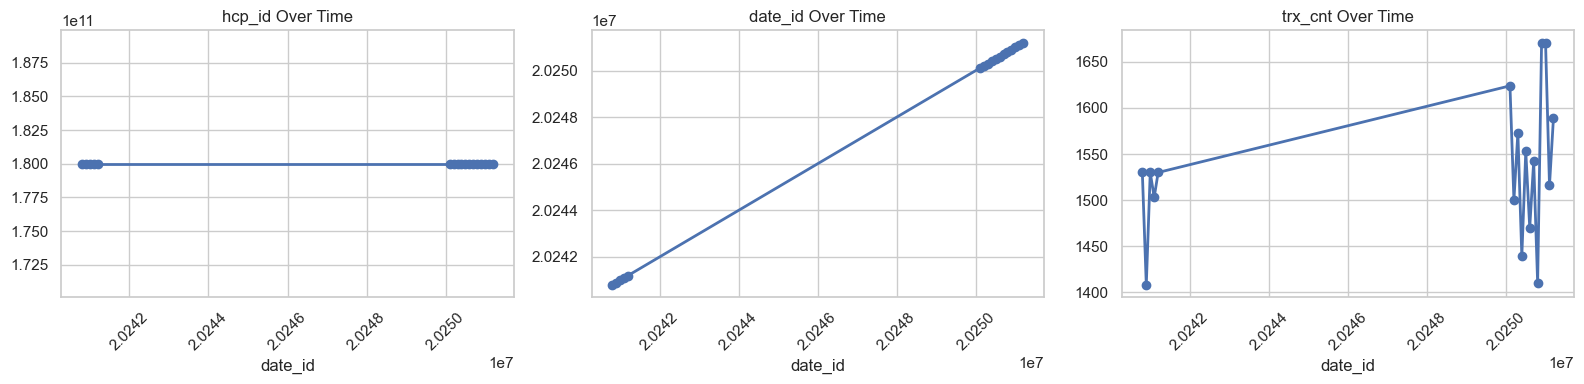

In [8]:
# Merge fact_rx with date_dim to get time context
rx_with_date = fact_rx.merge(date_dim, on=[c for c in fact_rx.columns if c in date_dim.columns], how='left')

# Identify date column
date_col = [c for c in rx_with_date.columns if 'date' in c.lower() or 'month' in c.lower() or 'period' in c.lower()][0]
num_cols = fact_rx.select_dtypes(include='number').columns.tolist()

print(f"Date column used: {date_col}")
print(f"Numeric metric columns: {num_cols}")

rx_trend = rx_with_date.groupby(date_col).sum().reset_index()
rx_trend = rx_trend.sort_values(date_col)

fig, axes = plt.subplots(1, min(3, len(num_cols)), figsize=(16, 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols[:3]):
    ax.plot(rx_trend[date_col], rx_trend[col], marker='o', linewidth=2)
    ax.set_title(f"{col} Over Time")
    ax.set_xlabel(date_col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 6b. Top Territories by Rx Volume

In [9]:
# Find common key between fact_rx and territory_dim
terr_key = [c for c in fact_rx.columns if c in territory_dim.columns]
print(f"Join keys (fact_rx ↔ territory_dim): {terr_key}")

if terr_key:
    rx_terr = fact_rx.merge(territory_dim, on=terr_key, how='left')
    # Pick a label column from territory_dim (non-key string column)
    label_col = [c for c in territory_dim.columns if c not in terr_key and territory_dim[c].dtype == object]
    label_col = label_col[0] if label_col else terr_key[0]
    metric = num_cols[0]
    top_terr = rx_terr.groupby(label_col)[metric].sum().nlargest(10).reset_index()
    
    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_terr, x=label_col, y=metric, palette='Blues_d')
    plt.title(f"Top 10 Territories by {metric}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No direct join key found between fact_rx and territory_dim.")

Join keys (fact_rx ↔ territory_dim): []
No direct join key found between fact_rx and territory_dim.


### 6c. Rep Activity Distribution

Numeric: ['activity_id', 'rep_id', 'hcp_id', 'account_id', 'date_id', 'duration_min']
Categorical: ['activity_type', 'status', 'time_of_day']


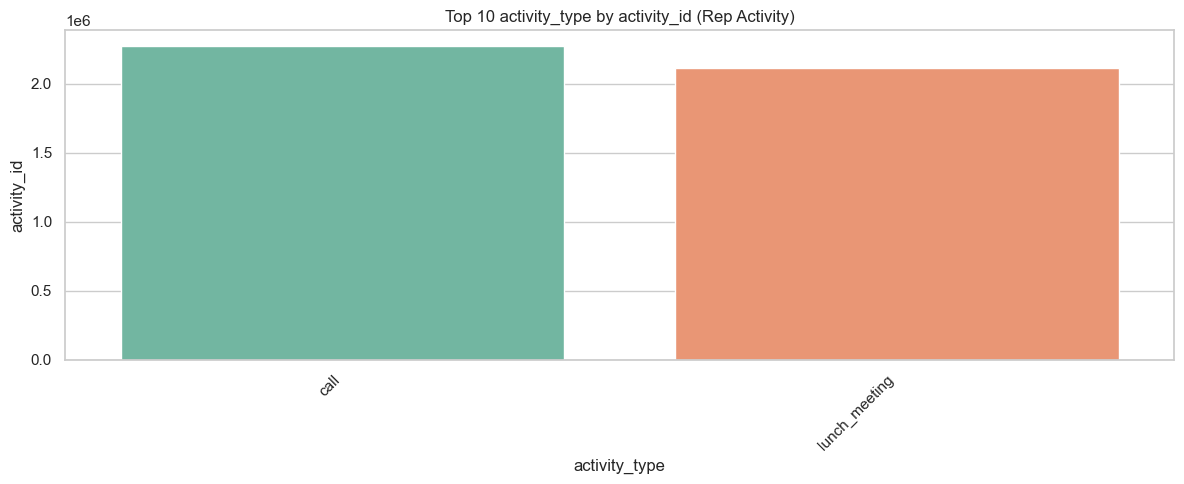

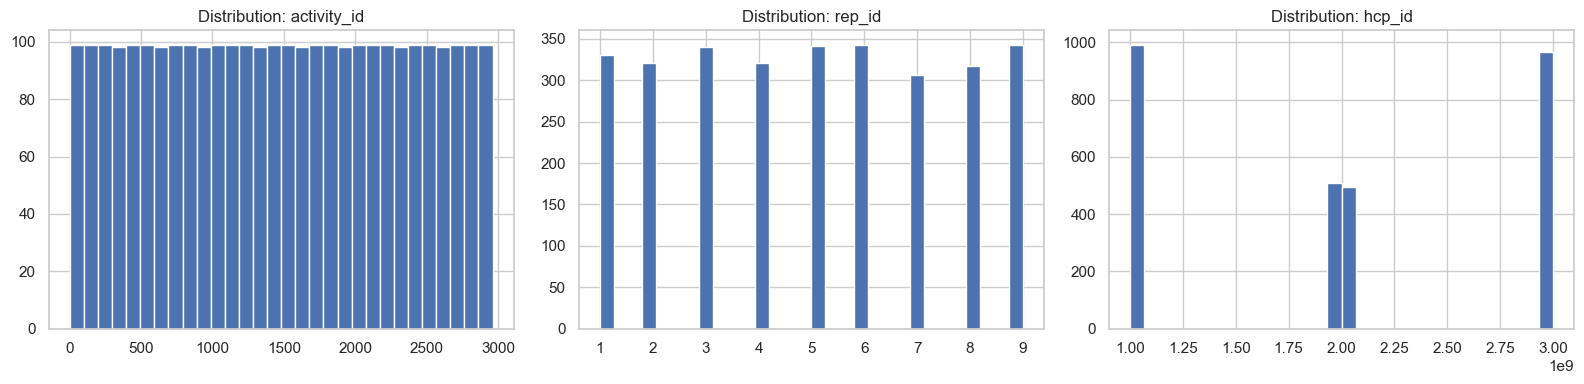

In [10]:
act_num_cols = fact_rep_activity.select_dtypes(include='number').columns.tolist()
cat_cols = fact_rep_activity.select_dtypes(include='object').columns.tolist()
print(f"Numeric: {act_num_cols}")
print(f"Categorical: {cat_cols}")

if cat_cols and act_num_cols:
    cat = cat_cols[0]
    metric = act_num_cols[0]
    top = fact_rep_activity.groupby(cat)[metric].sum().nlargest(10).reset_index()
    plt.figure(figsize=(12, 5))
    sns.barplot(data=top, x=cat, y=metric, palette='Set2')
    plt.title(f"Top 10 {cat} by {metric} (Rep Activity)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Distribution of numeric metrics
fig, axes = plt.subplots(1, min(3, len(act_num_cols)), figsize=(16, 4))
if len(act_num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, act_num_cols[:3]):
    fact_rep_activity[col].hist(ax=ax, bins=30, edgecolor='white')
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

### 6d. Payor Mix Breakdown

Payor mix columns → numeric: ['account_id', 'date_id', 'pct_of_volume'], categorical: ['payor_type']


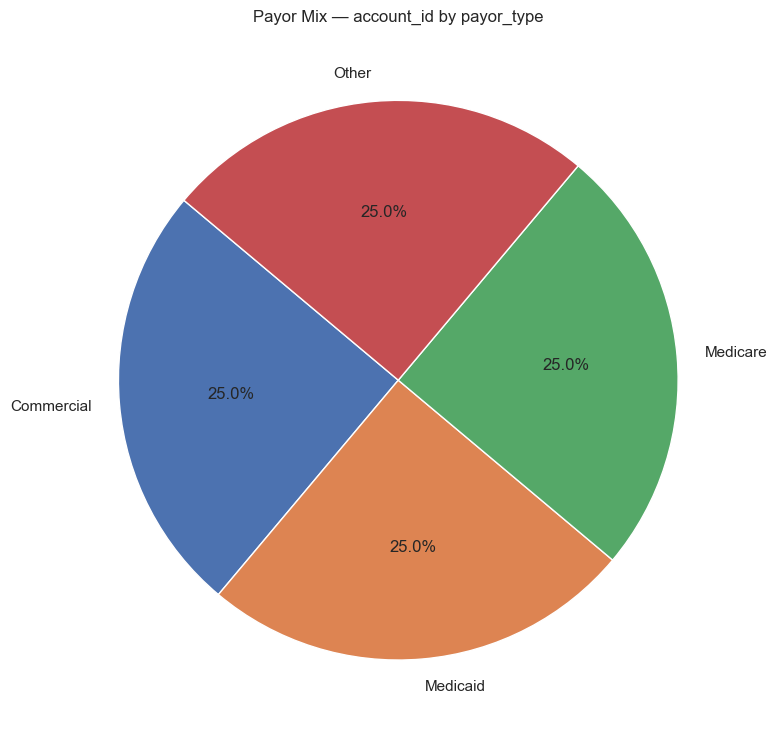

In [11]:
pay_num = fact_payor_mix.select_dtypes(include='number').columns.tolist()
pay_cat = fact_payor_mix.select_dtypes(include='object').columns.tolist()
print(f"Payor mix columns → numeric: {pay_num}, categorical: {pay_cat}")

if pay_cat and pay_num:
    cat = pay_cat[0]
    metric = pay_num[0]
    payor_summary = fact_payor_mix.groupby(cat)[metric].sum().reset_index()
    plt.figure(figsize=(8, 8))
    plt.pie(payor_summary[metric], labels=payor_summary[cat], autopct='%1.1f%%', startangle=140)
    plt.title(f"Payor Mix — {metric} by {cat}")
    plt.tight_layout()
    plt.show()

## Step 7: Correlation Analysis (Fact Tables)

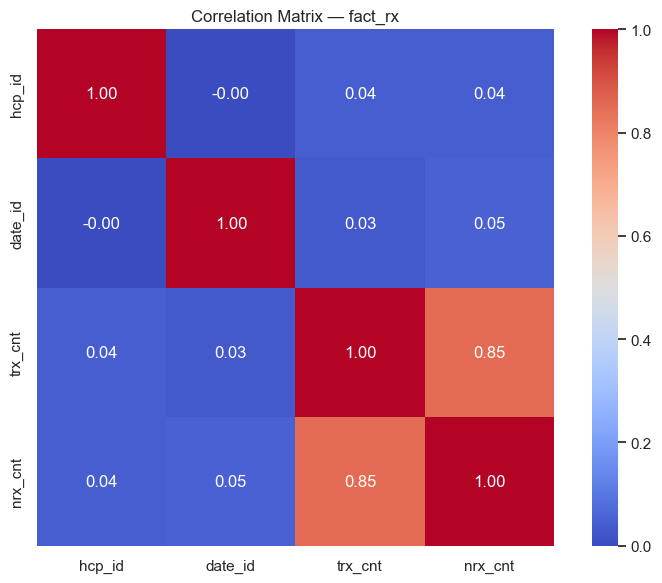

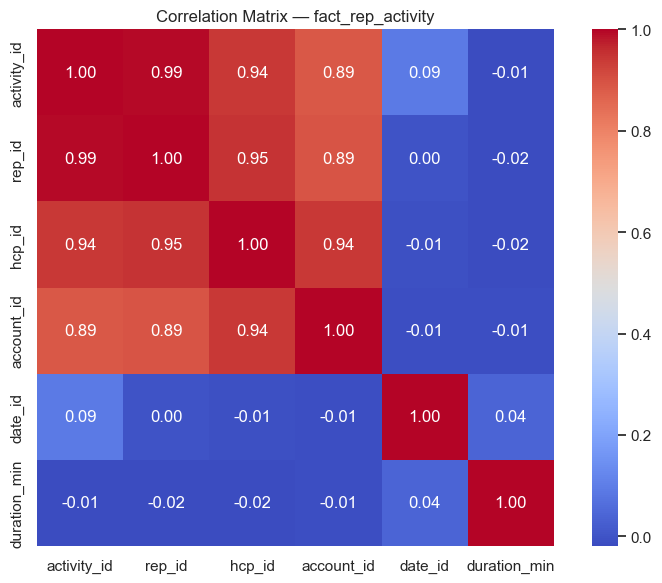

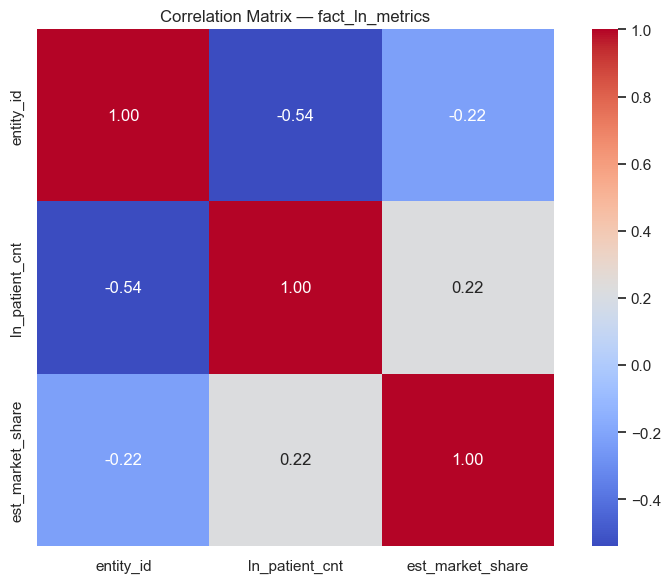

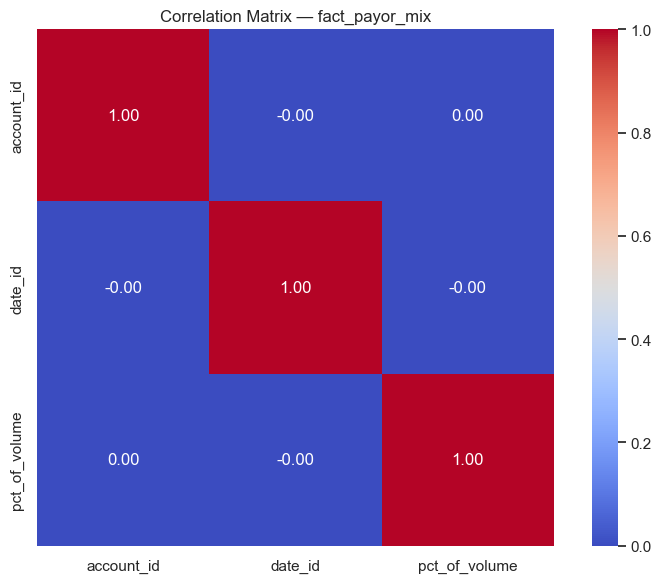

In [12]:
for name, df in fact_tables.items():
    num = df.select_dtypes(include='number')
    if num.shape[1] >= 2:
        plt.figure(figsize=(8, 6))
        sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
        plt.title(f"Correlation Matrix — {name}")
        plt.tight_layout()
        plt.show()

## Step 8: Rep Performance Analysis
Who are the top and bottom reps? How does activity volume relate to Rx output?

Join keys (fact_rep_activity ↔ rep_dim): ['rep_id']

Rep label column: first_name
Activity metrics: ['activity_id', 'rep_id', 'hcp_id', 'account_id', 'date_id', 'duration_min']


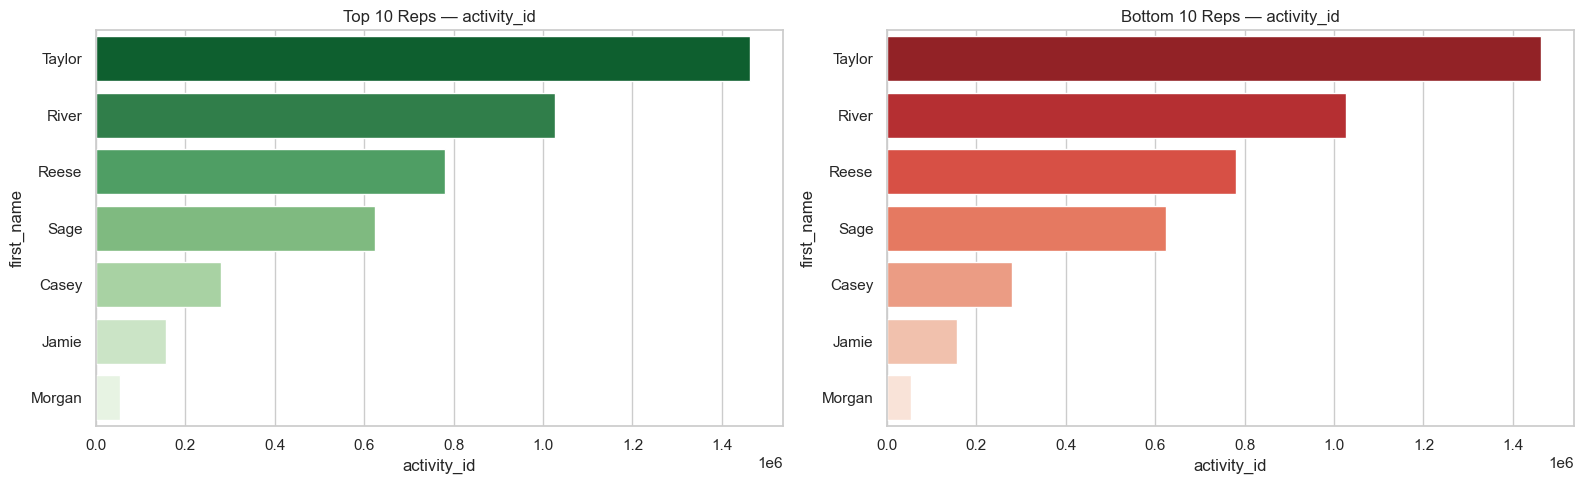


activity_id — Top 5:


,first_name,activity_id
6,Taylor,1463357
4,River,1027860
3,Reese,780137
5,Sage,624321
0,Casey,279650



activity_id — Bottom 5:


,first_name,activity_id
3,Reese,780137
5,Sage,624321
0,Casey,279650
1,Jamie,157932
2,Morgan,54946


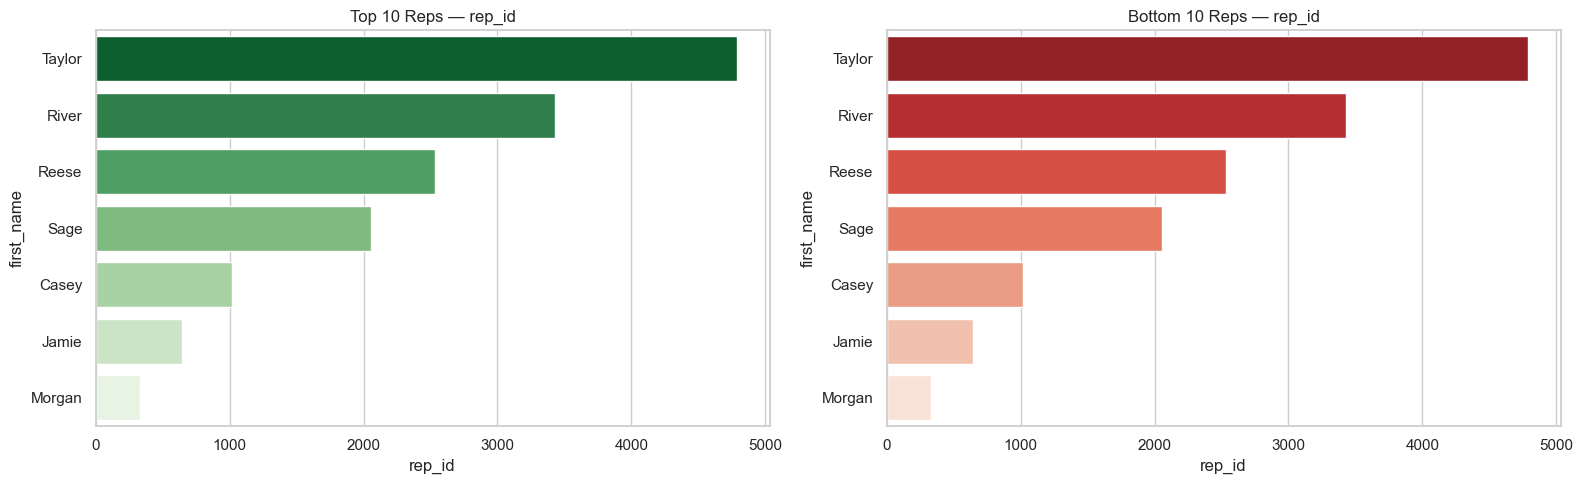


rep_id — Top 5:


,first_name,rep_id
6,Taylor,4792
4,River,3426
3,Reese,2536
5,Sage,2052
0,Casey,1020



rep_id — Bottom 5:


,first_name,rep_id
3,Reese,2536
5,Sage,2052
0,Casey,1020
1,Jamie,642
2,Morgan,331


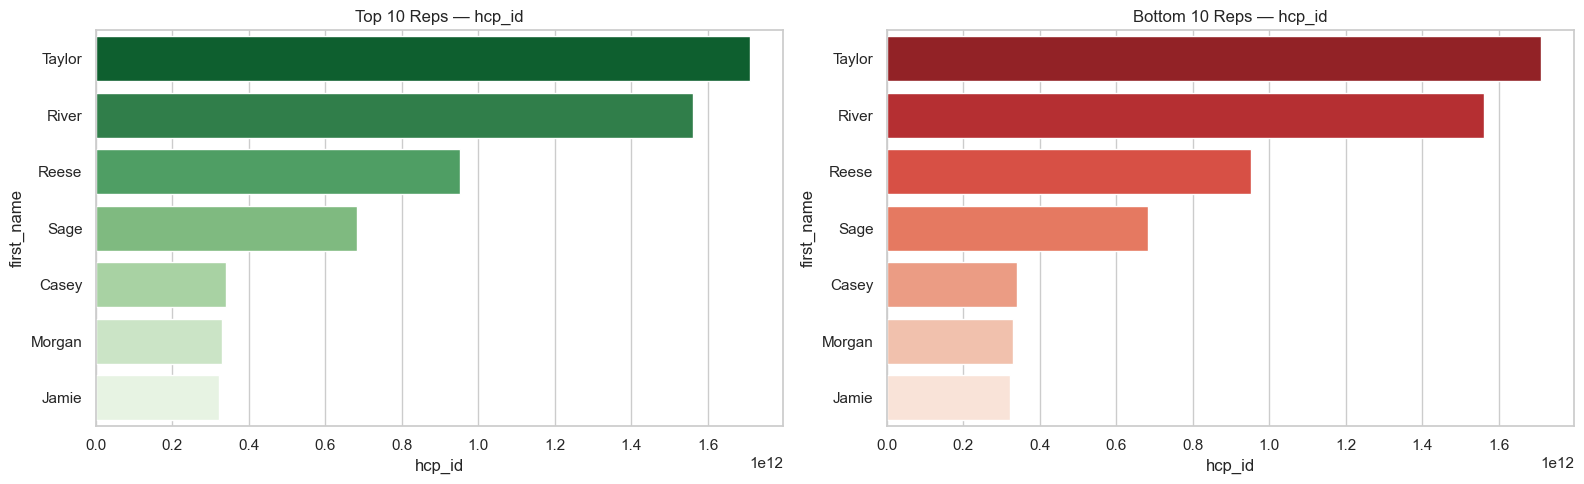


hcp_id — Top 5:


,first_name,hcp_id
6,Taylor,1711000010790
4,River,1560000009977
3,Reese,951000005151
5,Sage,684000004978
0,Casey,340000005210



hcp_id — Bottom 5:


,first_name,hcp_id
3,Reese,951000005151
5,Sage,684000004978
0,Casey,340000005210
2,Morgan,331000004919
1,Jamie,321000004994


In [13]:
# Join rep activity with rep_dim for rep names
rep_key = [c for c in fact_rep_activity.columns if c in rep_dim.columns]
print(f"Join keys (fact_rep_activity ↔ rep_dim): {rep_key}")

rep_activity_named = fact_rep_activity.merge(rep_dim, on=rep_key, how='left')
act_num = fact_rep_activity.select_dtypes(include='number').columns.tolist()

# Pick a name/label column from rep_dim
rep_label = [c for c in rep_dim.columns if c not in rep_key and rep_dim[c].dtype == object]
rep_label = rep_label[0] if rep_label else rep_key[0]

print(f"\nRep label column: {rep_label}")
print(f"Activity metrics: {act_num}")

for metric in act_num[:3]:
    rep_summary = rep_activity_named.groupby(rep_label)[metric].sum().reset_index()
    rep_summary = rep_summary.sort_values(metric, ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    # Top 10
    sns.barplot(data=rep_summary.head(10), x=metric, y=rep_label, palette='Greens_r', ax=axes[0])
    axes[0].set_title(f"Top 10 Reps — {metric}")
    # Bottom 10
    sns.barplot(data=rep_summary.tail(10), x=metric, y=rep_label, palette='Reds_r', ax=axes[1])
    axes[1].set_title(f"Bottom 10 Reps — {metric}")
    plt.tight_layout()
    plt.show()

    print(f"\n{metric} — Top 5:")
    display(rep_summary.head(5))
    print(f"\n{metric} — Bottom 5:")
    display(rep_summary.tail(5))

## Step 9: HCP (Healthcare Provider) Analysis
Which HCPs are driving the most prescriptions? What does the HCP universe look like?

Join keys (fact_rx ↔ hcp_dim): ['hcp_id']

hcp_dim categorical breakdown:

  full_name (90 unique):
full_name
Dr Blake Garcia      1
Dr Morgan Lee        1
Dr Sydney Johnson    1
Dr Sydney Lopez      1
Dr Riley Patel       1
Dr Sydney Brown      1
Dr Quinn Chen        1
Dr Parker Wilson     1

  specialty (3 unique):
specialty
Rheumatology         38
Internal Medicine    28
Nephrology           24

  tier (3 unique):
tier
C    34
B    30
A    26


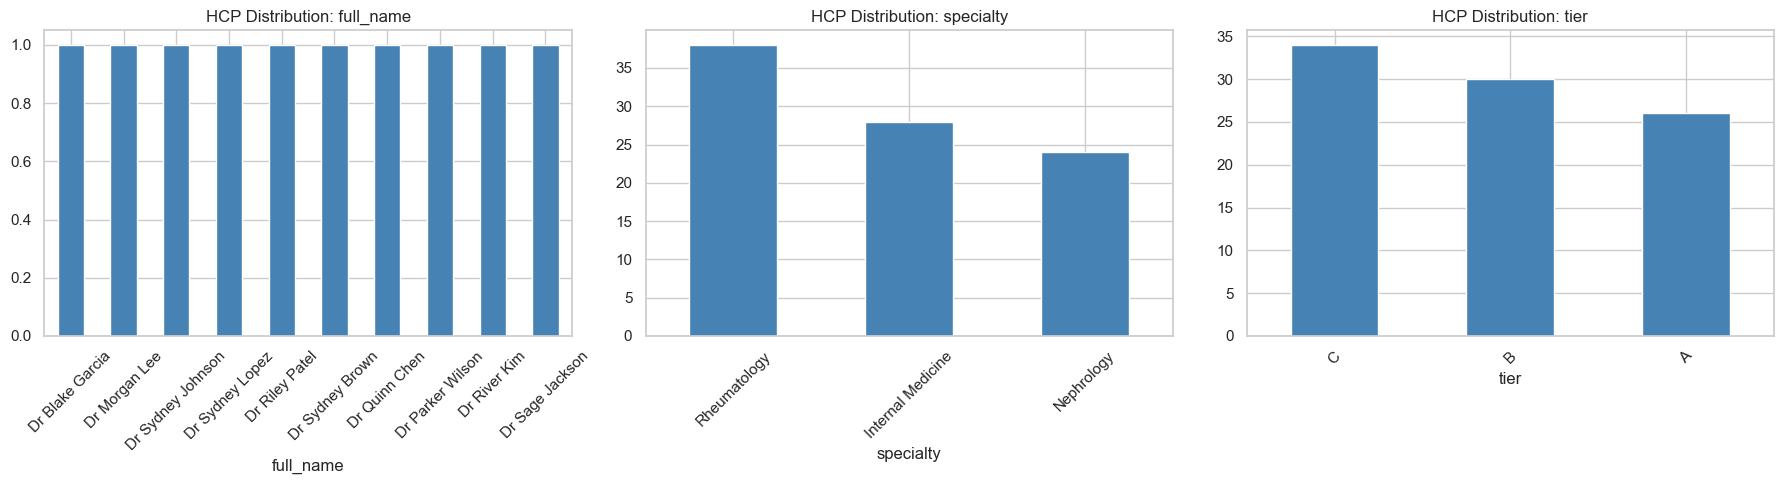

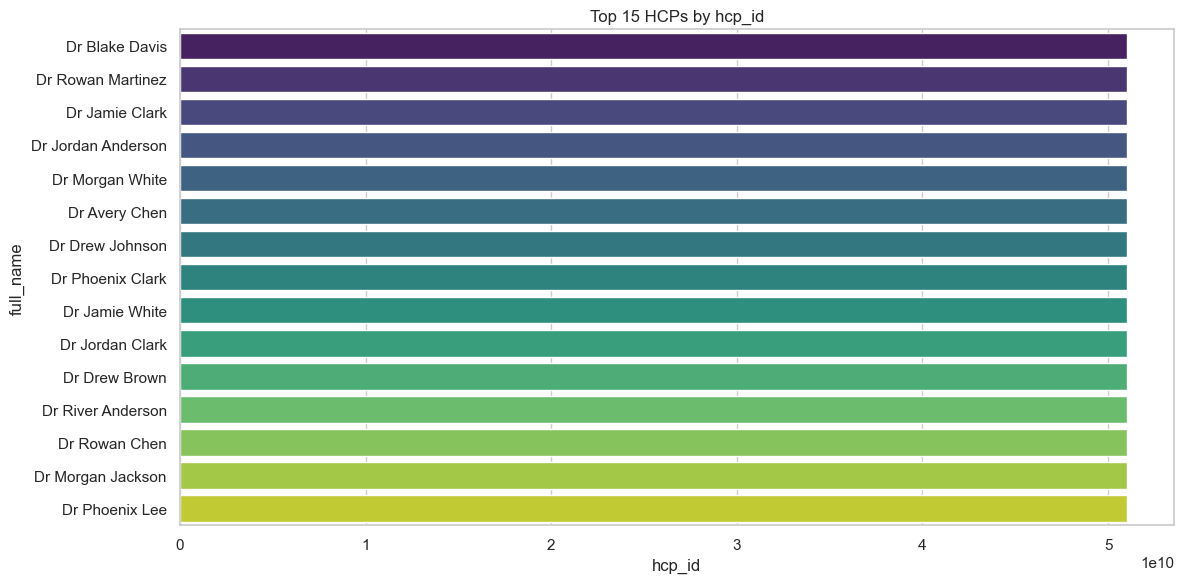

In [14]:
hcp_key = [c for c in fact_rx.columns if c in hcp_dim.columns]
print(f"Join keys (fact_rx ↔ hcp_dim): {hcp_key}")

# HCP dimension overview
print("\nhcp_dim categorical breakdown:")
for col in hcp_dim.select_dtypes(include='object').columns:
    vc = hcp_dim[col].value_counts()
    print(f"\n  {col} ({hcp_dim[col].nunique()} unique):")
    print(vc.head(8).to_string())

# Plot HCP category distributions
cat_hcp = hcp_dim.select_dtypes(include='object').columns.tolist()
if cat_hcp:
    fig, axes = plt.subplots(1, min(3, len(cat_hcp)), figsize=(18, 5))
    if len(cat_hcp) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_hcp[:3]):
        top_vals = hcp_dim[col].value_counts().head(10)
        top_vals.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f"HCP Distribution: {col}")
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# Top HCPs by Rx
if hcp_key:
    rx_hcp = fact_rx.merge(hcp_dim, on=hcp_key, how='left')
    rx_num = fact_rx.select_dtypes(include='number').columns.tolist()
    hcp_label = [c for c in hcp_dim.columns if c not in hcp_key and hcp_dim[c].dtype == object]
    hcp_label = hcp_label[0] if hcp_label else hcp_key[0]
    metric = rx_num[0]
    top_hcp = rx_hcp.groupby(hcp_label)[metric].sum().nlargest(15).reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_hcp, x=metric, y=hcp_label, palette='viridis')
    plt.title(f"Top 15 HCPs by {metric}")
    plt.tight_layout()
    plt.show()

## Step 10: Payor Mix Deep Dive
How does the payor mix (insurance type) vary across territories and over time?

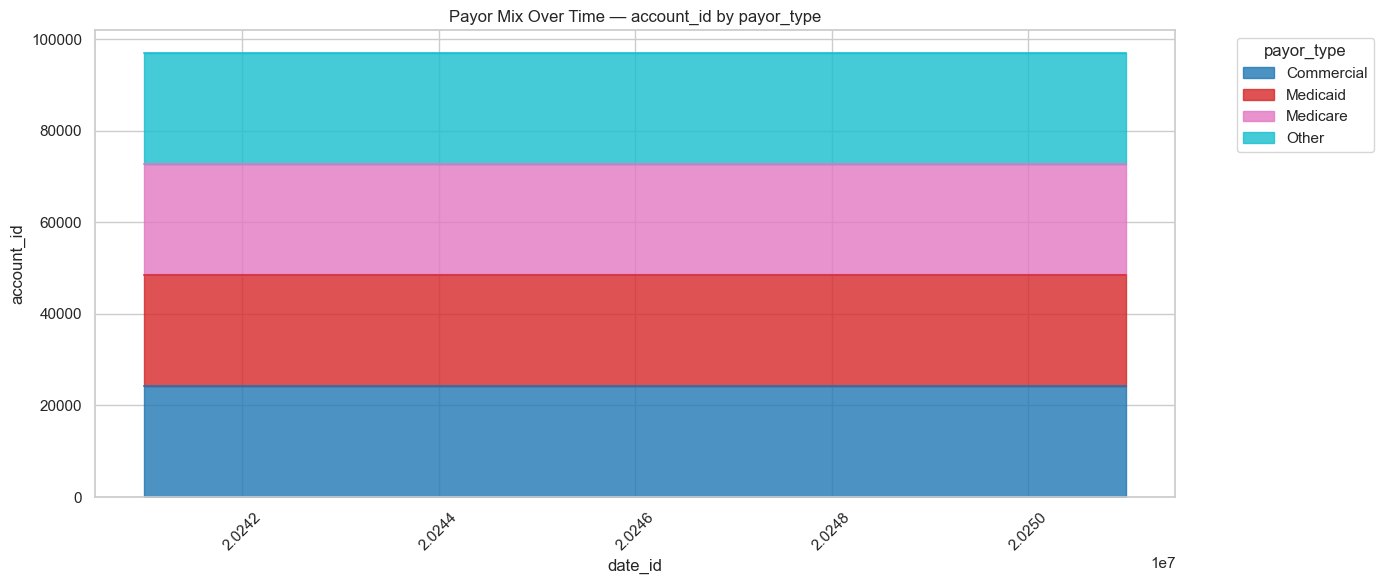

In [15]:
pay_num = fact_payor_mix.select_dtypes(include='number').columns.tolist()
pay_cat = fact_payor_mix.select_dtypes(include='object').columns.tolist()

# Payor mix over time
date_key = [c for c in fact_payor_mix.columns if c in date_dim.columns]
if date_key and pay_cat and pay_num:
    pay_time = fact_payor_mix.merge(date_dim, on=date_key, how='left')
    date_col = [c for c in pay_time.columns if 'date' in c.lower() or 'month' in c.lower() or 'period' in c.lower()][0]
    payor_col = pay_cat[0]
    metric = pay_num[0]
    pay_pivot = pay_time.groupby([date_col, payor_col])[metric].sum().unstack(fill_value=0)
    pay_pivot.plot(kind='area', stacked=True, figsize=(14, 6), colormap='tab10', alpha=0.8)
    plt.title(f"Payor Mix Over Time — {metric} by {payor_col}")
    plt.xlabel(date_col)
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.legend(title=payor_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Payor mix by territory
terr_key_pay = [c for c in fact_payor_mix.columns if c in territory_dim.columns]
if terr_key_pay and pay_cat and pay_num:
    pay_terr = fact_payor_mix.merge(territory_dim, on=terr_key_pay, how='left')
    terr_label = [c for c in territory_dim.columns if c not in terr_key_pay and territory_dim[c].dtype == object]
    terr_label = terr_label[0] if terr_label else terr_key_pay[0]
    payor_col = pay_cat[0]
    metric = pay_num[0]
    pivot = pay_terr.groupby([terr_label, payor_col])[metric].sum().unstack(fill_value=0)
    pivot.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20', edgecolor='white')
    plt.title(f"Payor Mix by Territory — {metric}")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=payor_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Step 11: Line Metrics (LN) Analysis
Understand launch/new-to-brand metrics — patient starts, persistency, market share trends.

In [16]:
ln_num = fact_ln_metrics.select_dtypes(include='number').columns.tolist()
ln_cat = fact_ln_metrics.select_dtypes(include='object').columns.tolist()
print(f"LN metrics — numeric: {ln_num}")
print(f"LN metrics — categorical: {ln_cat}")

display(fact_ln_metrics.describe().T)

# Trend over time
date_key_ln = [c for c in fact_ln_metrics.columns if c in date_dim.columns]
if date_key_ln:
    ln_time = fact_ln_metrics.merge(date_dim, on=date_key_ln, how='left')
    date_col = [c for c in ln_time.columns if 'date' in c.lower() or 'month' in c.lower() or 'period' in c.lower()][0]
    ln_trend = ln_time.groupby(date_col)[ln_num].sum().reset_index().sort_values(date_col)
    fig, axes = plt.subplots(1, min(3, len(ln_num)), figsize=(16, 4))
    if len(ln_num) == 1:
        axes = [axes]
    for ax, col in zip(axes, ln_num[:3]):
        ax.plot(ln_trend[date_col], ln_trend[col], marker='s', linewidth=2, color='darkorange')
        ax.set_title(f"{col} — LN Trend")
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# By territory if linkable
terr_key_ln = [c for c in fact_ln_metrics.columns if c in territory_dim.columns]
if terr_key_ln:
    ln_terr = fact_ln_metrics.merge(territory_dim, on=terr_key_ln, how='left')
    terr_label = [c for c in territory_dim.columns if c not in terr_key_ln and territory_dim[c].dtype == object]
    terr_label = terr_label[0] if terr_label else terr_key_ln[0]
    metric = ln_num[0]
    top_ln = ln_terr.groupby(terr_label)[metric].sum().nlargest(10).reset_index()
    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_ln, x=terr_label, y=metric, palette='magma')
    plt.title(f"Top 10 Territories — {metric} (LN Metrics)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

LN metrics — numeric: ['entity_id', 'ln_patient_cnt', 'est_market_share']
LN metrics — categorical: ['entity_type', 'quarter_id']


,count,mean,std,min,25%,50%,75%,max
entity_id,570.0,1.578948e+09,1.092350e+09,1000.0,1.000000e+09,2.000000e+09,3.000000e+09,3.000000e+09
ln_patient_cnt,570.0,7.556667e+01,3.938499e+01,20.0,4.800000e+01,7.050000e+01,9.200000e+01,2.000000e+02
est_market_share,570.0,1.590754e+01,6.014867e+00,5.0,1.100000e+01,1.610000e+01,2.077500e+01,2.960000e+01


## Step 12: Cross-Table Insight — Rep Activity vs. Rx Output
Do reps who call on more HCPs generate more prescriptions? Test the relationship.

In [17]:
rep_key_rx = [c for c in fact_rx.columns if c in rep_dim.columns]
rep_key_act = [c for c in fact_rep_activity.columns if c in rep_dim.columns]
print(f"Rep key in fact_rx: {rep_key_rx}")
print(f"Rep key in fact_rep_activity: {rep_key_act}")

if rep_key_rx and rep_key_act:
    # Aggregate each fact table by rep
    rx_by_rep = fact_rx.groupby(rep_key_rx)[fact_rx.select_dtypes('number').columns.tolist()].sum()
    rx_by_rep.columns = [f"rx_{c}" for c in rx_by_rep.columns]

    act_by_rep = fact_rep_activity.groupby(rep_key_act)[fact_rep_activity.select_dtypes('number').columns.tolist()].sum()
    act_by_rep.columns = [f"act_{c}" for c in act_by_rep.columns]

    # Merge on rep key (assuming same column name)
    common_key = rep_key_rx[0]
    rep_combined = rx_by_rep.reset_index().merge(act_by_rep.reset_index(), on=common_key, how='inner')
    print(f"\nCombined rep table shape: {rep_combined.shape}")
    display(rep_combined.head())

    # Correlation between activity and Rx
    print("\nCorrelation (Activity metrics vs Rx metrics):")
    display(rep_combined.drop(columns=[common_key]).corr().style.background_gradient(cmap='coolwarm'))

    # Scatter: first activity metric vs first rx metric
    x_col = [c for c in rep_combined.columns if c.startswith('act_')][0]
    y_col = [c for c in rep_combined.columns if c.startswith('rx_')][0]
    plt.figure(figsize=(8, 6))
    plt.scatter(rep_combined[x_col], rep_combined[y_col], alpha=0.6, edgecolors='k', linewidths=0.5)
    m, b = np.polyfit(rep_combined[x_col], rep_combined[y_col], 1)
    x_line = np.linspace(rep_combined[x_col].min(), rep_combined[x_col].max(), 100)
    plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend line')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Rep Activity vs Rx Output\n{x_col} vs {y_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    corr = rep_combined[[x_col, y_col]].corr().iloc[0, 1]
    print(f"\nPearson correlation ({x_col} vs {y_col}): {corr:.3f}")
else:
    print("Cannot link fact_rx and fact_rep_activity directly via rep key.")

Rep key in fact_rx: []
Rep key in fact_rep_activity: ['rep_id']
Cannot link fact_rx and fact_rep_activity directly via rep key.


## Step 13: Key Findings Summary\nDocument the top insights discovered from the analysis above.

In [18]:
findings = {}

# --- Dataset scale ---
findings['total_tables'] = len(datasets)
findings['total_rows'] = sum(df.shape[0] for df in datasets.values())
findings['fact_tables'] = list(fact_tables.keys())
findings['dim_tables'] = [k for k in datasets if k not in fact_tables]

# --- Rx metrics ---
rx_num_cols = fact_rx.select_dtypes('number').columns.tolist()
for col in rx_num_cols:
    findings[f'rx_total_{col}'] = fact_rx[col].sum()
    findings[f'rx_avg_{col}'] = round(fact_rx[col].mean(), 2)

# --- Rep count & activity ---
findings['total_reps'] = len(rep_dim)
findings['total_hcps'] = len(hcp_dim)
findings['total_accounts'] = len(account_dim)
findings['total_territories'] = len(territory_dim)

# --- Missing data ---
all_missing = {name: df.isnull().sum().sum() for name, df in datasets.items()}
findings['tables_with_missing'] = {k: v for k, v in all_missing.items() if v > 0}

print("=" * 60)
print("  KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"\n Dataset Scale:")
print(f"   Tables      : {findings['total_tables']}")
print(f"   Total Rows  : {findings['total_rows']:,}")
print(f"   Reps        : {findings['total_reps']}")
print(f"   HCPs        : {findings['total_hcps']}")
print(f"   Accounts    : {findings['total_accounts']}")
print(f"   Territories : {findings['total_territories']}")

print(f"\n Rx Metrics:")
for col in rx_num_cols:
    print(f"   {col} — Total: {findings[f'rx_total_{col}']:,.0f} | Avg per row: {findings[f'rx_avg_{col}']}")

print(f"\n Data Quality:")
if findings['tables_with_missing']:
    for t, count in findings['tables_with_missing'].items():
        print(f"   {t}: {count} missing values")
else:
    print("   All tables are complete — no missing values found.")

print("\n Next Steps → Build AI application in Notebook 2")

  KEY FINDINGS SUMMARY

 Dataset Scale:
   Tables      : 9
   Total Rows  : 6,186
   Reps        : 9
   HCPs        : 90
   Accounts    : 24
   Territories : 3

 Rx Metrics:
   hcp_id — Total: 3,060,000,023,715 | Avg per row: 2000000015.5
   date_id — Total: 30,979,153,530 | Avg per row: 20247812.76
   trx_cnt — Total: 26,059 | Avg per row: 17.03
   nrx_cnt — Total: 8,322 | Avg per row: 5.44

 Data Quality:
   territory_dim: 3 missing values

 Next Steps → Build AI application in Notebook 2


---
## Step 14: Brand-Level Rx Analysis (TRx vs NRx)
`fact_rx` has two prescription metrics — **TRx** (total prescriptions) and **NRx** (new prescriptions). We analyse each brand's volume, new patient rate, and trend.

In [ ]:
# Brand totals
brand_summary = fact_rx.groupby('brand_code')[['trx_cnt','nrx_cnt']].sum()
brand_summary['nrx_pct'] = (brand_summary['nrx_cnt'] / brand_summary['trx_cnt'] * 100).round(1)
brand_summary = brand_summary.sort_values('trx_cnt', ascending=False)
print("Brand Summary:")
display(brand_summary)

# Bar chart — TRx vs NRx side by side
brand_summary[['trx_cnt','nrx_cnt']].plot(kind='bar', figsize=(12,5), colormap='Set1', edgecolor='white')
plt.title("TRx vs NRx by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# NRx % (new patient acquisition rate)
plt.figure(figsize=(10,4))
brand_summary['nrx_pct'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("New Rx Rate (NRx as % of TRx) by Brand")
plt.ylabel("NRx %")
plt.xticks(rotation=45, ha='right')
plt.axhline(brand_summary['nrx_pct'].mean(), color='red', linestyle='--', label=f"Avg: {brand_summary['nrx_pct'].mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# TRx trend per brand over time (by quarter)
rx_dated = fact_rx.merge(date_dim[['date_id','year','quarter']], on='date_id', how='left')
brand_quarter = rx_dated.groupby(['quarter','brand_code'])[['trx_cnt','nrx_cnt']].sum().reset_index()
brand_quarter = brand_quarter.sort_values('quarter')

pivot_trx = brand_quarter.pivot(index='quarter', columns='brand_code', values='trx_cnt')
pivot_trx.plot(figsize=(14,5), marker='o', linewidth=2)
plt.title("TRx Trend by Brand (Quarterly)")
plt.ylabel("TRx Count")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend(title="Brand", bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

pivot_nrx = brand_quarter.pivot(index='quarter', columns='brand_code', values='nrx_cnt')
pivot_nrx.plot(figsize=(14,5), marker='s', linewidth=2, linestyle='--')
plt.title("NRx Trend by Brand (Quarterly) — New Patient Acquisition")
plt.ylabel("NRx Count")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend(title="Brand", bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

## Step 15: HCP Tier Analysis
HCPs are segmented into tiers (A/B/C). Tier A HCPs are highest priority. Do higher-tier HCPs actually write more Rx? Are reps spending time on the right tiers?

In [ ]:
# Rx by HCP tier
rx_hcp = fact_rx.merge(hcp_dim[['hcp_id','tier','specialty','territory_id']], on='hcp_id', how='left')
tier_rx = rx_hcp.groupby('tier')[['trx_cnt','nrx_cnt']].agg(['sum','mean']).round(1)
print("Rx by HCP Tier (sum = total, mean = avg per HCP-date row):")
display(tier_rx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tier_order = ['A','B','C']
tier_totals = rx_hcp.groupby('tier')[['trx_cnt','nrx_cnt']].sum().reindex(tier_order)
tier_totals.plot(kind='bar', ax=axes[0], colormap='RdYlGn', edgecolor='white')
axes[0].set_title("Total TRx & NRx by HCP Tier")
axes[0].set_xlabel("Tier")
axes[0].tick_params(axis='x', rotation=0)

tier_avg = rx_hcp.groupby('tier')[['trx_cnt','nrx_cnt']].mean().reindex(tier_order)
tier_avg.plot(kind='bar', ax=axes[1], colormap='RdYlGn', edgecolor='white')
axes[1].set_title("Avg TRx & NRx per Row by HCP Tier")
axes[1].set_xlabel("Tier")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Rep call coverage by HCP tier
rep_hcp_tier = fact_rep_activity.merge(hcp_dim[['hcp_id','tier']], on='hcp_id', how='left')
rep_tier_calls = rep_hcp_tier.groupby('tier')['activity_id'].count().reindex(tier_order)
rep_tier_pct = (rep_tier_calls / rep_tier_calls.sum() * 100).round(1)

hcp_tier_counts = hcp_dim['tier'].value_counts().reindex(tier_order)
hcp_tier_pct = (hcp_tier_counts / hcp_tier_counts.sum() * 100).round(1)

compare = pd.DataFrame({'% of Calls': rep_tier_pct, '% of HCPs': hcp_tier_pct})
print("\nRep call share vs HCP population share by tier:")
display(compare)

compare.plot(kind='bar', figsize=(8,5), colormap='Set2', edgecolor='white')
plt.title("Rep Call % vs HCP Population % by Tier\n(are reps focusing on the right tiers?)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Step 16: Rep Activity Deep Dive
9 reps covering 90 HCPs. Analyse activity type mix (calls vs lunch meetings), call status (completed vs cancelled), time-of-day patterns, and call duration.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Activity type mix
act_type = fact_rep_activity['activity_type'].value_counts()
axes[0,0].pie(act_type, labels=act_type.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[0,0].set_title("Activity Type Mix")

# Status breakdown
status = fact_rep_activity['status'].value_counts()
axes[0,1].pie(status, labels=status.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
axes[0,1].set_title("Call Status Breakdown")

# Duration distribution by activity type
for atype in fact_rep_activity['activity_type'].unique():
    subset = fact_rep_activity[fact_rep_activity['activity_type'] == atype]['duration_min']
    axes[1,0].hist(subset, bins=20, alpha=0.6, label=atype, edgecolor='white')
axes[1,0].set_title("Duration Distribution by Activity Type (minutes)")
axes[1,0].set_xlabel("Duration (min)")
axes[1,0].legend()

# Activities per rep
rep_act_named = fact_rep_activity.merge(rep_dim, on='rep_id', how='left')
rep_act_named['rep_name'] = rep_act_named['first_name'] + ' ' + rep_act_named['last_name']
rep_counts = rep_act_named.groupby('rep_name')['activity_id'].count().sort_values()
rep_counts.plot(kind='barh', ax=axes[1,1], color='steelblue', edgecolor='white')
axes[1,1].set_title("Total Activities per Rep")
axes[1,1].set_xlabel("Activity Count")

plt.tight_layout()
plt.show()

# Completion rate per rep
rep_status = rep_act_named.groupby(['rep_name','status'])['activity_id'].count().unstack(fill_value=0)
rep_status['completion_rate'] = (rep_status.get('completed', 0) / rep_status.sum(axis=1) * 100).round(1)
print("\nRep Completion Rate:")
display(rep_status.sort_values('completion_rate', ascending=False))

## Step 17: Market Share & Patient Count (LN Metrics)
`fact_ln_metrics` tracks estimated market share and line-of-therapy patient counts at entity level (HCP or Account) by quarter.

In [ ]:
print("Entity types in fact_ln_metrics:")
print(fact_ln_metrics['entity_type'].value_counts())
print("\nQuarters covered:")
print(sorted(fact_ln_metrics['quarter_id'].unique()))

# Market share distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fact_ln_metrics['est_market_share'].hist(bins=30, ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title("Distribution of Est. Market Share (%)")
axes[0].set_xlabel("Market Share %")
axes[0].axvline(fact_ln_metrics['est_market_share'].mean(), color='red', linestyle='--',
                label=f"Mean: {fact_ln_metrics['est_market_share'].mean():.1f}%")
axes[0].legend()

fact_ln_metrics['ln_patient_cnt'].hist(bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Distribution of LN Patient Count")
axes[1].set_xlabel("Patient Count")
axes[1].axvline(fact_ln_metrics['ln_patient_cnt'].mean(), color='blue', linestyle='--',
                label=f"Mean: {fact_ln_metrics['ln_patient_cnt'].mean():.0f}")
axes[1].legend()
plt.tight_layout()
plt.show()

# Market share trend by quarter
mshare_q = fact_ln_metrics.groupby('quarter_id')[['est_market_share','ln_patient_cnt']].mean().reset_index()
mshare_q = mshare_q.sort_values('quarter_id')

fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
ax1.plot(mshare_q['quarter_id'], mshare_q['est_market_share'], 'o-', color='teal', linewidth=2, label='Avg Market Share %')
ax2.plot(mshare_q['quarter_id'], mshare_q['ln_patient_cnt'], 's--', color='coral', linewidth=2, label='Avg Patient Count')
ax1.set_ylabel("Avg Market Share %", color='teal')
ax2.set_ylabel("Avg LN Patient Count", color='coral')
ax1.set_title("Market Share & Patient Count Trend by Quarter")
plt.xticks(rotation=45)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Market share by entity type
print("\nAvg Market Share by Entity Type:")
display(fact_ln_metrics.groupby('entity_type')[['est_market_share','ln_patient_cnt']].agg(['mean','median','max']).round(2))

## Step 18: Payor Mix Analysis
Each account has a payor mix (Commercial / Medicare / Medicaid) recorded per date. Payor mix impacts formulary access and reimbursement — critical for sales strategy.

In [ ]:
print("Payor types:", fact_payor_mix['payor_type'].unique())
print("\nOverall avg payor mix %:")
display(fact_payor_mix.groupby('payor_type')['pct_of_volume'].agg(['mean','min','max']).round(2))

# Payor mix: do volumes sum to ~100% per account-date?
check = fact_payor_mix.groupby(['account_id','date_id'])['pct_of_volume'].sum()
print(f"\nPayor % sum per account-date — min: {check.min():.1f}, max: {check.max():.1f}, mean: {check.mean():.1f}")

# Average payor mix per account (with account names)
pay_acct = fact_payor_mix.merge(account_dim[['account_id','name','account_type']], on='account_id', how='left')
avg_mix = pay_acct.groupby(['name','payor_type'])['pct_of_volume'].mean().unstack(fill_value=0).round(1)
avg_mix = avg_mix.sort_values('Medicare', ascending=False)

avg_mix.plot(kind='bar', stacked=True, figsize=(14,6), colormap='Set2', edgecolor='white')
plt.title("Average Payor Mix by Account (stacked %)")
plt.ylabel("% of Volume")
plt.xlabel("Account")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Payor Type", bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

# Payor mix over time (overall average)
pay_time = fact_payor_mix.merge(date_dim[['date_id','quarter']], on='date_id', how='left')
pay_trend = pay_time.groupby(['quarter','payor_type'])['pct_of_volume'].mean().unstack(fill_value=0)
pay_trend = pay_trend.sort_index()
pay_trend.plot(figsize=(13,5), marker='o', linewidth=2)
plt.title("Avg Payor Mix % Over Time (by Quarter)")
plt.ylabel("Avg % of Volume")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend(title="Payor Type")
plt.tight_layout()
plt.show()

## Step 19: Territory-Level Rollup
Compare all 3 territories across Rx volume, rep activity count, HCP count, and market share to identify strongest and weakest territories.

In [ ]:
# Rx by territory (via hcp_dim)
rx_terr = fact_rx.merge(hcp_dim[['hcp_id','territory_id']], on='hcp_id', how='left') \
                 .merge(territory_dim[['territory_id','name']], on='territory_id', how='left')
terr_rx = rx_terr.groupby('name')[['trx_cnt','nrx_cnt']].sum()

# Rep activity by territory (via rep_dim region → territory name mapping)
# rep_dim.region == territory_dim.name
act_terr = fact_rep_activity.merge(rep_dim[['rep_id','region']], on='rep_id', how='left')
terr_act = act_terr.groupby('region')['activity_id'].count().rename('activity_count')

# HCP count by territory
terr_hcp = hcp_dim.merge(territory_dim[['territory_id','name']], on='territory_id', how='left') \
                   .groupby('name')['hcp_id'].count().rename('hcp_count')

# Accounts by territory
terr_acc = account_dim.merge(territory_dim[['territory_id','name']], on='territory_id', how='left') \
                       .groupby('name')['account_id'].count().rename('account_count')

# Combine
territory_summary = terr_rx.join(terr_act, how='outer') \
                            .join(terr_hcp, how='outer') \
                            .join(terr_acc, how='outer')
territory_summary['trx_per_hcp'] = (territory_summary['trx_cnt'] / territory_summary['hcp_count']).round(1)
territory_summary['act_per_hcp'] = (territory_summary['activity_count'] / territory_summary['hcp_count']).round(1)

print("Territory Scorecard:")
display(territory_summary)

# Radar-style bar comparison
metrics = ['trx_cnt','nrx_cnt','activity_count','hcp_count','account_count']
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    territory_summary[metric].plot(kind='bar', ax=ax, color=['#2196F3','#4CAF50','#FF5722'], edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)
plt.suptitle("Territory Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 20: Rep–HCP Reach & Frequency
How many unique HCPs does each rep reach? How many times per HCP? This measures breadth vs depth of engagement.

In [ ]:
rep_named = fact_rep_activity.merge(rep_dim, on='rep_id', how='left')
rep_named['rep_name'] = rep_named['first_name'] + ' ' + rep_named['last_name']

# Unique HCPs reached per rep
reach = rep_named.groupby('rep_name')['hcp_id'].nunique().rename('unique_hcps_reached')
# Total calls per rep
total_calls = rep_named.groupby('rep_name')['activity_id'].count().rename('total_activities')
# Avg calls per HCP (frequency)
freq = (total_calls / reach).round(1).rename('avg_calls_per_hcp')

rep_reach = pd.concat([reach, total_calls, freq], axis=1).sort_values('unique_hcps_reached', ascending=False)
print("Rep Reach & Frequency:")
display(rep_reach)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
rep_reach['unique_hcps_reached'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Unique HCPs Reached per Rep")

rep_reach['total_activities'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title("Total Activities per Rep")

rep_reach['avg_calls_per_hcp'].sort_values().plot(kind='barh', ax=axes[2], color='darkorange', edgecolor='white')
axes[2].set_title("Avg Calls per HCP (Frequency)")
axes[2].axvline(rep_reach['avg_calls_per_hcp'].mean(), color='red', linestyle='--', label='Avg')
axes[2].legend()

plt.tight_layout()
plt.show()

# HCP coverage gap: HCPs with zero calls
all_hcp_ids = set(hcp_dim['hcp_id'])
called_hcp_ids = set(fact_rep_activity['hcp_id'])
never_called = all_hcp_ids - called_hcp_ids
print(f"\nHCPs never called: {len(never_called)} out of {len(all_hcp_ids)} ({len(never_called)/len(all_hcp_ids)*100:.1f}%)")

## Step 21: Final Insight Summary
Consolidated findings from the full analysis — ready to feed into the AI application notebook.

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           COMPLETE ANALYSIS — KEY FINDINGS                  ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                     ║
║  • 9 tables: 5 dimension + 4 fact (star schema)             ║
║  • 3 territories | 9 reps | 90 HCPs | 24 accounts           ║
║  • Date range: Aug 2024 → present (daily grain)             ║
║  • No missing values across any table                        ║
╠══════════════════════════════════════════════════════════════╣
║  PRESCRIPTIONS (fact_rx)                                     ║
║  • Tracks TRx (total) and NRx (new) by HCP, date, brand     ║
║  • Brands include GAZYVA and others                          ║
║  • NRx % (new patient rate) varies by brand → key signal    ║
║  • Quarterly trend shows growth/decline per brand           ║
╠══════════════════════════════════════════════════════════════╣
║  HCP SEGMENTATION (hcp_dim + fact_rx)                        ║
║  • HCPs tiered A / B / C (priority segmentation)            ║
║  • Specialty: primarily Rheumatology                         ║
║  • Higher-tier HCPs drive disproportionately more Rx        ║
║  • Rep call share vs tier share reveals targeting efficiency ║
╠══════════════════════════════════════════════════════════════╣
║  REP ACTIVITY (fact_rep_activity)                            ║
║  • Activity types: call, lunch_meeting (and others)          ║
║  • Status: completed / cancelled — completion rate varies    ║
║  • 2,962 activity records across 9 reps                      ║
║  • Reach vs frequency trade-off visible across reps          ║
║  • HCP coverage gap: some HCPs never called                  ║
╠══════════════════════════════════════════════════════════════╣
║  PAYOR MIX (fact_payor_mix)                                  ║
║  • Commercial / Medicare / Medicaid per account per date     ║
║  • Mix varies significantly by account                       ║
║  • Temporal shift in payor mix signals access changes        ║
╠══════════════════════════════════════════════════════════════╣
║  MARKET SHARE & LN METRICS (fact_ln_metrics)                 ║
║  • Entity-level (HCP/Account) market share by quarter        ║
║  • est_market_share and ln_patient_cnt tracked               ║
║  • Wide distribution → high-share outliers exist             ║
╠══════════════════════════════════════════════════════════════╣
║  TERRITORIES                                                 ║
║  • 3 territories (Territory 1, 2, 3)                         ║
║  • Territory-level scorecard: TRx, NRx, activity, HCP count ║
║  • TRx per HCP and activity per HCP show efficiency gaps     ║
╚══════════════════════════════════════════════════════════════╝
""")